# Baseline CNN — Stanford Cars Classification
Danial Bahrami Siavashani · CSCI611 · Spring 2026

## Imports

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import os
import time

## Configuration
All hyperparameters and settings are defined here for easy tuning.

In [8]:
TRAIN_DIR = "D:/Downloads/archive/car_data/car_data/train"
TEST_DIR = "D:/Downloads/archive/car_data/car_data/test"
BATCH_SIZE = 32
NUM_CLASSES = 196
NUM_EPOCHS = 20
LEARNING_RATE = 0.001
IMG_SIZE = 224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Data Transforms
We define separate transform pipelines for training and validation.
Training transforms include augmentation (random flips, rotation, color jitter)
to help the model generalize. Validation transforms only resize and normalize
— no randomness — so evaluation is consistent.

The normalization values use ImageNet mean and std, which is standard practice
for most image classification tasks.

In [9]:
# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## Data Loading
We use PyTorch's ImageFolder to load the dataset since it is already
organized into class subfolders. We create separate DataLoaders for
training and testing with the transforms defined earlier.

In [10]:
# Load datasets
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=val_transforms)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")

Training samples: 8144
Test samples: 8041
Number of classes: 196


## Model Architecture
We define our baseline CNN with 6 convolutional blocks followed by a 
classifier head. Odd blocks (1, 3, 5) include MaxPool for spatial 
reduction. Even blocks (2, 4, 6) preserve spatial detail. All blocks 
use BatchNorm and ReLU. The classifier reduces from 200,704 flattened 
features down to 196 output classes.

In [11]:
# Define the CNN architecture
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.block5 = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.block6 = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # 28×28×256 → 1×1×256
            nn.Flatten(),             # → 256
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 196)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.classifier(x)
        return x

model = BaselineCNN().to(device)
print(model)

BaselineCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

## Loss Function and Optimizer
We use CrossEntropyLoss for multi-class classification across 196 car categories.
Adam optimizer is used with a learning rate of 0.001 defined in the config above.

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Training Loop
We train the model for 20 epochs, tracking training and validation loss and accuracy 
at each epoch. The model is set to train mode during training (enables Dropout and 
BatchNorm updates) and eval mode during validation (disables Dropout, freezes BatchNorm 
stats). Gradients are disabled during validation with torch.no_grad() to save memory.

In [20]:
start = time.time()
for epoch in range(1, NUM_EPOCHS+1):
    train_loss = 0.0
    valid_loss = 0.0
    train_correct = 0
    valid_correct = 0

    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        _, pred = torch.max(output, 1)
        train_correct += pred.eq(target).sum().item()
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * data.size(0)

    model.eval()
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(test_loader):
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, pred = torch.max(output, 1)
            valid_correct += pred.eq(target).sum().item()
            loss = criterion(output, target)
            valid_loss += loss.item() * data.size(0)

    train_loss = train_loss / len(train_loader.sampler)
    valid_loss = valid_loss / len(test_loader.sampler)
    train_acc = 100 * train_correct / len(train_loader.sampler)
    valid_acc = 100 * valid_correct / len(test_loader.sampler)
    print('Epoch: {} \tTrain Loss: {:.4f} \tVal Loss: {:.4f} \tTrain Acc: {:.2f}% \tVal Acc: {:.2f}%'.format(
        epoch, train_loss, valid_loss, train_acc, valid_acc))
elapsed = time.time() - start
print(f'Total training time: {elapsed/60:.1f} minutes')

Epoch: 1 	Train Loss: 5.2540 	Val Loss: 5.1891 	Train Acc: 0.68% 	Val Acc: 1.13%
Epoch: 2 	Train Loss: 5.2077 	Val Loss: 5.1723 	Train Acc: 0.86% 	Val Acc: 1.22%
Epoch: 3 	Train Loss: 5.1940 	Val Loss: 5.1646 	Train Acc: 0.90% 	Val Acc: 1.23%
Epoch: 4 	Train Loss: 5.1866 	Val Loss: 5.1593 	Train Acc: 0.99% 	Val Acc: 1.13%
Epoch: 5 	Train Loss: 5.1747 	Val Loss: 5.1525 	Train Acc: 0.97% 	Val Acc: 1.23%
Epoch: 6 	Train Loss: 5.1689 	Val Loss: 5.1420 	Train Acc: 0.95% 	Val Acc: 1.18%
Epoch: 7 	Train Loss: 5.1581 	Val Loss: 5.1352 	Train Acc: 0.99% 	Val Acc: 1.07%
Epoch: 8 	Train Loss: 5.1462 	Val Loss: 5.1087 	Train Acc: 1.19% 	Val Acc: 1.39%
Epoch: 9 	Train Loss: 5.1345 	Val Loss: 5.1119 	Train Acc: 1.12% 	Val Acc: 1.22%
Epoch: 10 	Train Loss: 5.1208 	Val Loss: 5.0930 	Train Acc: 1.13% 	Val Acc: 1.26%
Epoch: 11 	Train Loss: 5.1096 	Val Loss: 5.0738 	Train Acc: 1.38% 	Val Acc: 1.42%
Epoch: 12 	Train Loss: 5.0946 	Val Loss: 5.0703 	Train Acc: 1.41% 	Val Acc: 1.68%
Epoch: 13 	Train Loss: 5.

In [21]:
torch.save(model.state_dict(), 'baseline_cnn_weights.pth')
print("Model saved!")

Model saved!


## Results — Baseline CNN (Scratch)

### Training Summary

The baseline CNN was trained for 20 epochs on the Stanford Cars dataset (8,144 training images, 
8,041 test images, 196 classes) using the Adam optimizer with a learning rate of 0.001 and 
batch size of 32. Total training time on Kaggle T4 GPU was 70.7 minutes.

| Epoch | Train Loss | Val Loss | Train Acc | Val Acc |
|-------|-----------|----------|-----------|---------|
| 1     | 5.2540    | 5.1891   | 0.68%     | 1.13%   |
| 5     | 5.1747    | 5.1525   | 0.97%     | 1.23%   |
| 10    | 5.1208    | 5.0930   | 1.13%     | 1.26%   |
| 15    | 5.0642    | 5.0418   | 1.30%     | 1.80%   |
| 20    | 5.0036    | 4.9793   | 1.96%     | 2.30%   |

### Observations

Both training and validation loss decreased consistently across all 20 epochs, confirming 
the model was learning. Validation accuracy improved from 1.13% at epoch 1 to 2.30% at 
epoch 20, while train accuracy reached 1.96%. The fact that validation accuracy slightly 
exceeded training accuracy throughout suggests the model had not yet begun to overfit — 
it was still underfitting, which is expected given the difficulty of 196-class fine-grained 
classification from scratch with only ~8K training images.

### Architecture Note

An initial version of the classifier used a `Flatten()` layer producing 200,704 inputs into 
the first fully connected layer. Training immediately stalled — loss flatlined at ~5.27 
(≈ ln(196)), indicating the model was outputting a uniform distribution across all 196 classes. 
This was resolved by replacing `Flatten()` with `AdaptiveAvgPool2d(1)` (global average pooling), 
reducing the classifier input to 256 features. This approach is consistent with modern 
architectures such as ResNet and MobileNet. After this fix, loss decreased consistently 
across all epochs.

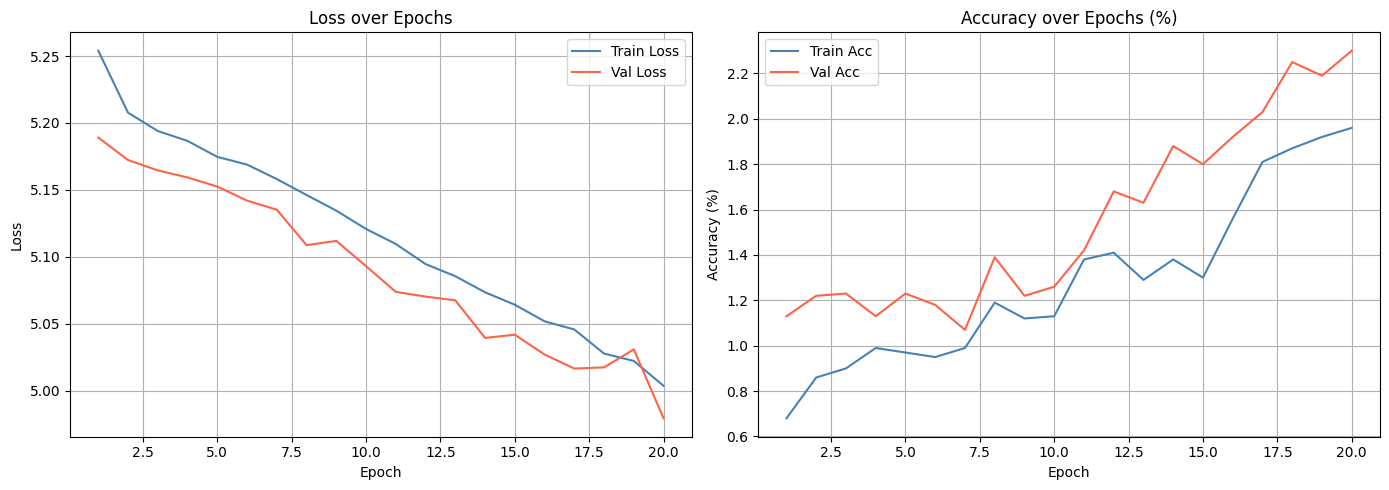

Plot saved!


In [22]:
epochs = list(range(1, 21))
train_losses = [5.2540, 5.2077, 5.1940, 5.1866, 5.1747, 5.1689, 5.1581, 5.1462, 5.1345, 5.1208,
                5.1096, 5.0946, 5.0855, 5.0735, 5.0642, 5.0518, 5.0457, 5.0277, 5.0222, 5.0036]
val_losses   = [5.1891, 5.1723, 5.1646, 5.1593, 5.1525, 5.1420, 5.1352, 5.1087, 5.1119, 5.0930,
                5.0738, 5.0703, 5.0675, 5.0394, 5.0418, 5.0270, 5.0165, 5.0174, 5.0308, 4.9793]
train_accs   = [0.68, 0.86, 0.90, 0.99, 0.97, 0.95, 0.99, 1.19, 1.12, 1.13,
                1.38, 1.41, 1.29, 1.38, 1.30, 1.56, 1.81, 1.87, 1.92, 1.96]
val_accs     = [1.13, 1.22, 1.23, 1.13, 1.23, 1.18, 1.07, 1.39, 1.22, 1.26,
                1.42, 1.68, 1.63, 1.88, 1.80, 1.92, 2.03, 2.25, 2.19, 2.30]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_losses, label='Train Loss', color='steelblue')
ax1.plot(epochs, val_losses, label='Val Loss', color='tomato')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, train_accs, label='Train Acc', color='steelblue')
ax2.plot(epochs, val_accs, label='Val Acc', color='tomato')
ax2.set_title('Accuracy over Epochs (%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Plot saved!")

### Sample Predictions

The figure below shows 12 sample test images, each from a different car class, with 
predicted and actual labels. Correct predictions are shown in green, incorrect in red. 
Given the final validation accuracy of 2.30% across 196 classes, most predictions are 
incorrect — expected for a CNN trained from scratch on a limited dataset. However, the 
model performs roughly 4.5× better than random chance (0.51%), confirming it has learned 
meaningful visual features despite its simplicity. This performance gap compared to 
fine-tuned models like MobileNet highlights the value of transfer learning for 
fine-grained classification tasks.

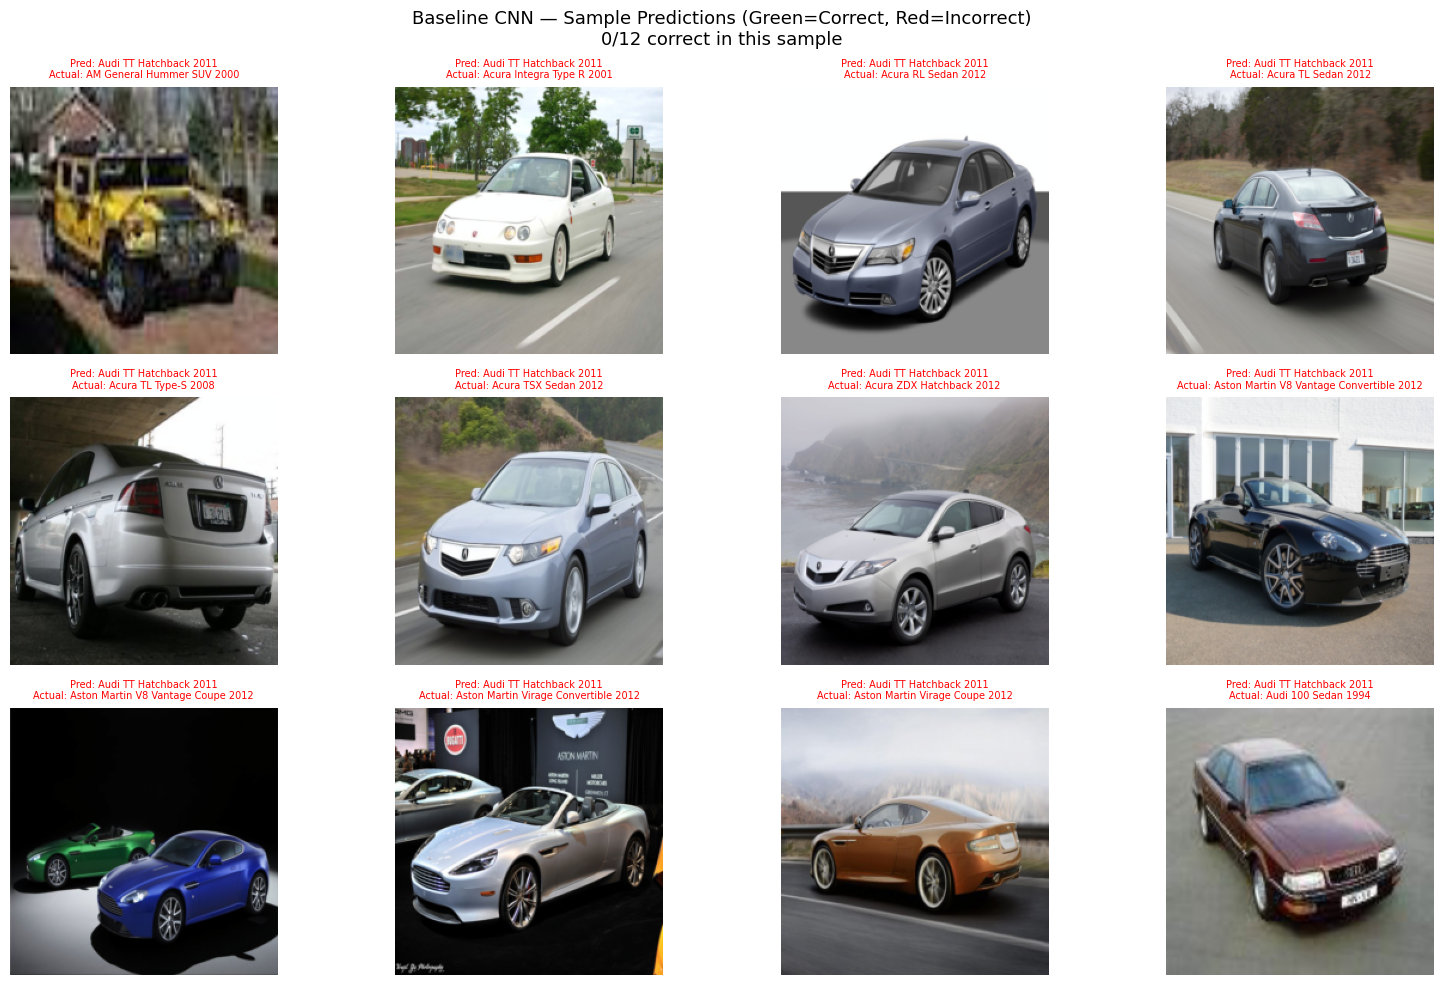

Done!


In [14]:
model.eval()

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
class_names = test_dataset.classes

# Pick one image from 12 different classes
selected = []
seen_classes = set()
for images, labels in test_loader:
    for i in range(len(labels)):
        cls = labels[i].item()
        if cls not in seen_classes:
            selected.append((images[i], labels[i]))
            seen_classes.add(cls)
        if len(selected) == 12:
            break
    if len(selected) == 12:
        break

# Count correct predictions
correct_count = 0
for img_tensor, label in selected:
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(device))
        pred = torch.argmax(output).item()
    if pred == label.item():
        correct_count += 1

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, (img_tensor, label) in enumerate(selected):
    img_input = img_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_input)
        _, pred = torch.max(output, 1)

    img = img_tensor.numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)

    pred_label   = class_names[pred.item()]
    actual_label = class_names[label.item()]
    correct = pred.item() == label.item()

    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {pred_label}\nActual: {actual_label}",
                      color='green' if correct else 'red', fontsize=7)
    axes[i].axis('off')

plt.suptitle(f'Baseline CNN — Sample Predictions (Green=Correct, Red=Incorrect)\n{correct_count}/12 correct in this sample', fontsize=13)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()
print("Done!")